<a href="https://colab.research.google.com/github/Ian-costermani/PS-Analytica_UFRJ/blob/main/analytica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Business Understanding
Este conjunto de dados contém transações de cartão de crédito realizadas por titulares de cartões europeus no ano de 2023. O objetivo principal deste projeto é  o desenvolvimento de algoritmos e modelos de detecção de fraude para identificar transações potencialmente fraudulentas.

# 2. Data Understanding
Este dataset compreende mais de 550.000 registos e os dados foram anonimizados para proteger as identidades dos titulares de cartões.

In [ ]:
#importando algumas bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score, ConfusionMatrixDisplay, f1_score
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
warnings.filterwarnings('ignore')

In [ ]:
#lendo o dataframe
df = pd.read_csv('/content/creditcard_2023.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568630 entries, 0 to 568629
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   id      568630 non-null  int64  
 1   V1      568630 non-null  float64
 2   V2      568630 non-null  float64
 3   V3      568630 non-null  float64
 4   V4      568630 non-null  float64
 5   V5      568630 non-null  float64
 6   V6      568630 non-null  float64
 7   V7      568630 non-null  float64
 8   V8      568630 non-null  float64
 9   V9      568630 non-null  float64
 10  V10     568630 non-null  float64
 11  V11     568630 non-null  float64
 12  V12     568630 non-null  float64
 13  V13     568630 non-null  float64
 14  V14     568630 non-null  float64
 15  V15     568630 non-null  float64
 16  V16     568630 non-null  float64
 17  V17     568630 non-null  float64
 18  V18     568630 non-null  float64
 19  V19     568630 non-null  float64
 20  V20     568630 non-null  float64
 21  V21     56



*   Por ser um dataset consideravelmente pesado (135 MB), será necessário uma otimização de memória


In [ ]:
def reduce_mem_usage(dataframe):
        # Reference: https://www.kaggle.com/competitions/playground-series-s4e7/discussion/516103#2899151

        print('--- Reducing memory usage')
        initial_mem_usage = dataframe.memory_usage().sum() / 1024**2

        for col in dataframe.columns:
            col_type = dataframe[col].dtype

            if col_type.name in ['object']:
                dataframe[col] = dataframe[col].astype('category')
                continue
            elif col_type.name not in ['object', 'category']:
              c_min = dataframe[col].min()
              c_max = dataframe[col].max()
              if str(col_type)[:3] == 'int':
                  if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    dataframe[col] = dataframe[col].astype(np.int8)
                  elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    dataframe[col] = dataframe[col].astype(np.int16)
                  elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    dataframe[col] = dataframe[col].astype(np.int32)
                  elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    dataframe[col] = dataframe[col].astype(np.int64)
              else:
                  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    dataframe[col] = dataframe[col].astype(np.float16)
                  elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    dataframe[col] = dataframe[col].astype(np.float32)
                  else:
                    dataframe[col] = dataframe[col].astype(np.float64)

        final_mem_usage = dataframe.memory_usage().sum() / 1024**2
        print('------ Memory usage before: {:.2f} MB'.format(initial_mem_usage))
        print('------ Memory usage after: {:.2f} MB'.format(final_mem_usage))
        print('------ Decreased memory usage by {:.1f}%'.format(100 * (initial_mem_usage - final_mem_usage) / initial_mem_usage))

        return dataframe

In [ ]:
df= reduce_mem_usage(df)
df

--- Reducing memory usage
------ Memory usage before: 134.49 MB
------ Memory usage after: 34.16 MB
------ Decreased memory usage by 74.6%


,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-0.260742,-0.469727,2.496094,-0.083740,0.129639,0.732910,0.519043,-0.130005,0.727051,...,-0.110535,0.217651,-0.134766,0.166016,0.126221,-0.434814,-0.081238,-0.151001,17984.0,0
1,1,0.984863,-0.355957,0.558105,-0.429688,0.277100,0.428711,0.406494,-0.133179,0.347412,...,-0.194946,-0.605957,0.079468,-0.577637,0.190063,0.296387,-0.248047,-0.064514,6532.0,0
2,2,-0.260254,-0.949219,1.728516,-0.458008,0.074036,1.419922,0.743652,-0.095581,-0.261230,...,-0.005020,0.703125,0.944824,-1.154297,-0.605469,-0.312988,-0.300293,-0.244751,2514.0,0
3,3,-0.152100,-0.508789,1.747070,-1.089844,0.249512,1.143555,0.518066,-0.065125,-0.205688,...,-0.146973,-0.038208,-0.213989,-1.893555,1.003906,-0.516113,-0.165283,0.048431,5384.0,0
4,4,-0.206787,-0.165283,1.527344,-0.448242,0.106140,0.530762,0.658691,-0.212646,1.049805,...,-0.106995,0.729492,-0.161621,0.312500,-0.414062,1.071289,0.023712,0.419189,14280.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
568625,568625,-0.833496,0.061890,-0.899902,0.904297,-1.001953,0.481445,-0.370361,0.189697,-0.937988,...,0.167480,0.419678,1.288086,-0.900879,0.560547,-0.006020,3.308594,0.081543,4396.0,1
568626,568626,-0.670410,-0.202881,-0.068115,-0.267334,-0.133667,0.237183,-0.016937,-0.147705,0.483887,...,0.031860,0.388184,-0.154297,-0.846680,-0.153442,1.960938,-1.528320,1.704102,4652.0,1
568627,568627,-0.312012,-0.004093,0.137573,-0.035889,-0.042297,0.121094,-0.070984,-0.020004,-0.122070,...,0.140747,0.536621,-0.211060,-0.448975,0.540039,-0.755859,-0.487549,-0.268799,23568.0,1
568628,568628,0.636719,-0.517090,-0.300781,-0.144531,0.130981,-0.294189,0.580566,-0.207764,0.893555,...,-0.060394,-0.195557,-0.175537,-0.554688,-0.099670,-1.434570,-0.159302,-0.076233,10160.0,1


In [ ]:
df.shape

(568630, 31)

## 2.1 Tratamento geral dos dados

**Verificando o balanceamento das classes**

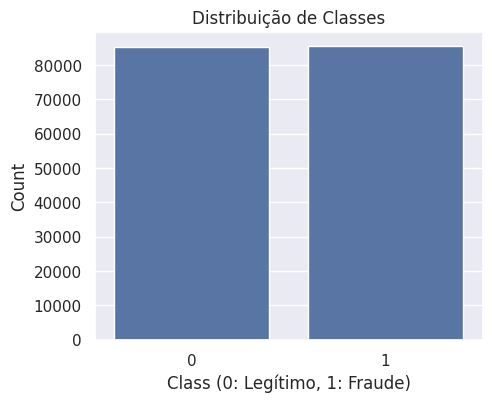

In [ ]:

plt.figure(figsize=(5, 4))
sns.countplot(x='Class', data=df)
plt.title('Distribuição de Classes')
plt.xlabel('Class (0: Legítimo, 1: Fraude)')
plt.ylabel('Count')
plt.show()

In [ ]:
df['Class'].value_counts()

,count
Class,
1,85440
0,85149


**Checando valores nulos**

In [ ]:
df.isnull().sum()

,0
id,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
#Removendo a variável id
df= df.drop('id', axis=1)



*  O dataset já está balanceado e sem valores NaN



## 2.2 Análise de features

In [ ]:
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-0.260742,-0.469727,2.496094,-0.083740,0.129639,0.732910,0.519043,-0.130005,0.727051,0.637695,...,-0.110535,0.217651,-0.134766,0.166016,0.126221,-0.434814,-0.081238,-0.151001,17984.0,0
1,0.984863,-0.355957,0.558105,-0.429688,0.277100,0.428711,0.406494,-0.133179,0.347412,0.529785,...,-0.194946,-0.605957,0.079468,-0.577637,0.190063,0.296387,-0.248047,-0.064514,6532.0,0
2,-0.260254,-0.949219,1.728516,-0.458008,0.074036,1.419922,0.743652,-0.095581,-0.261230,0.690918,...,-0.005020,0.703125,0.944824,-1.154297,-0.605469,-0.312988,-0.300293,-0.244751,2514.0,0
3,-0.152100,-0.508789,1.747070,-1.089844,0.249512,1.143555,0.518066,-0.065125,-0.205688,0.575195,...,-0.146973,-0.038208,-0.213989,-1.893555,1.003906,-0.516113,-0.165283,0.048431,5384.0,0
4,-0.206787,-0.165283,1.527344,-0.448242,0.106140,0.530762,0.658691,-0.212646,1.049805,0.968262,...,-0.106995,0.729492,-0.161621,0.312500,-0.414062,1.071289,0.023712,0.419189,14280.0,0


<Axes: >

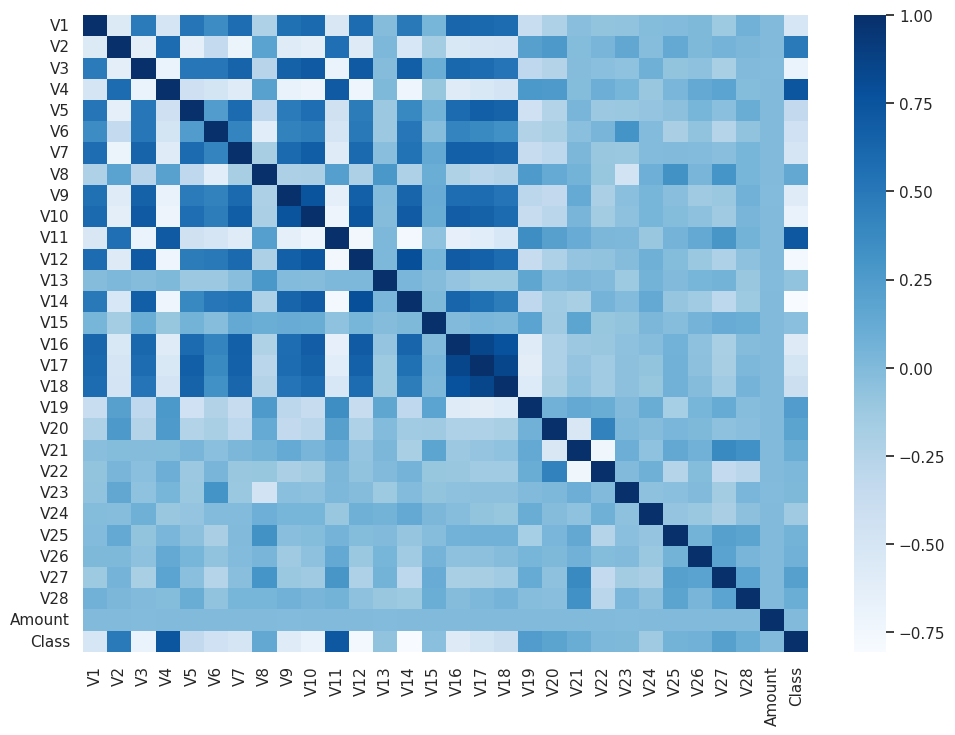

In [ ]:
sns.set(rc={'figure.figsize':(11.7,8.27)})
sns.heatmap(df.corr(), cmap='Blues', annot=False)



*   As variáveis V2, V4 e V11 são as que tem maior correlação positiva com o Target, e as variáveis V12 e V14 possúem forte relação negativa com o Target.
*   Algumas variáveis como V16,V17 e V18 possúem forte correlação entre si.



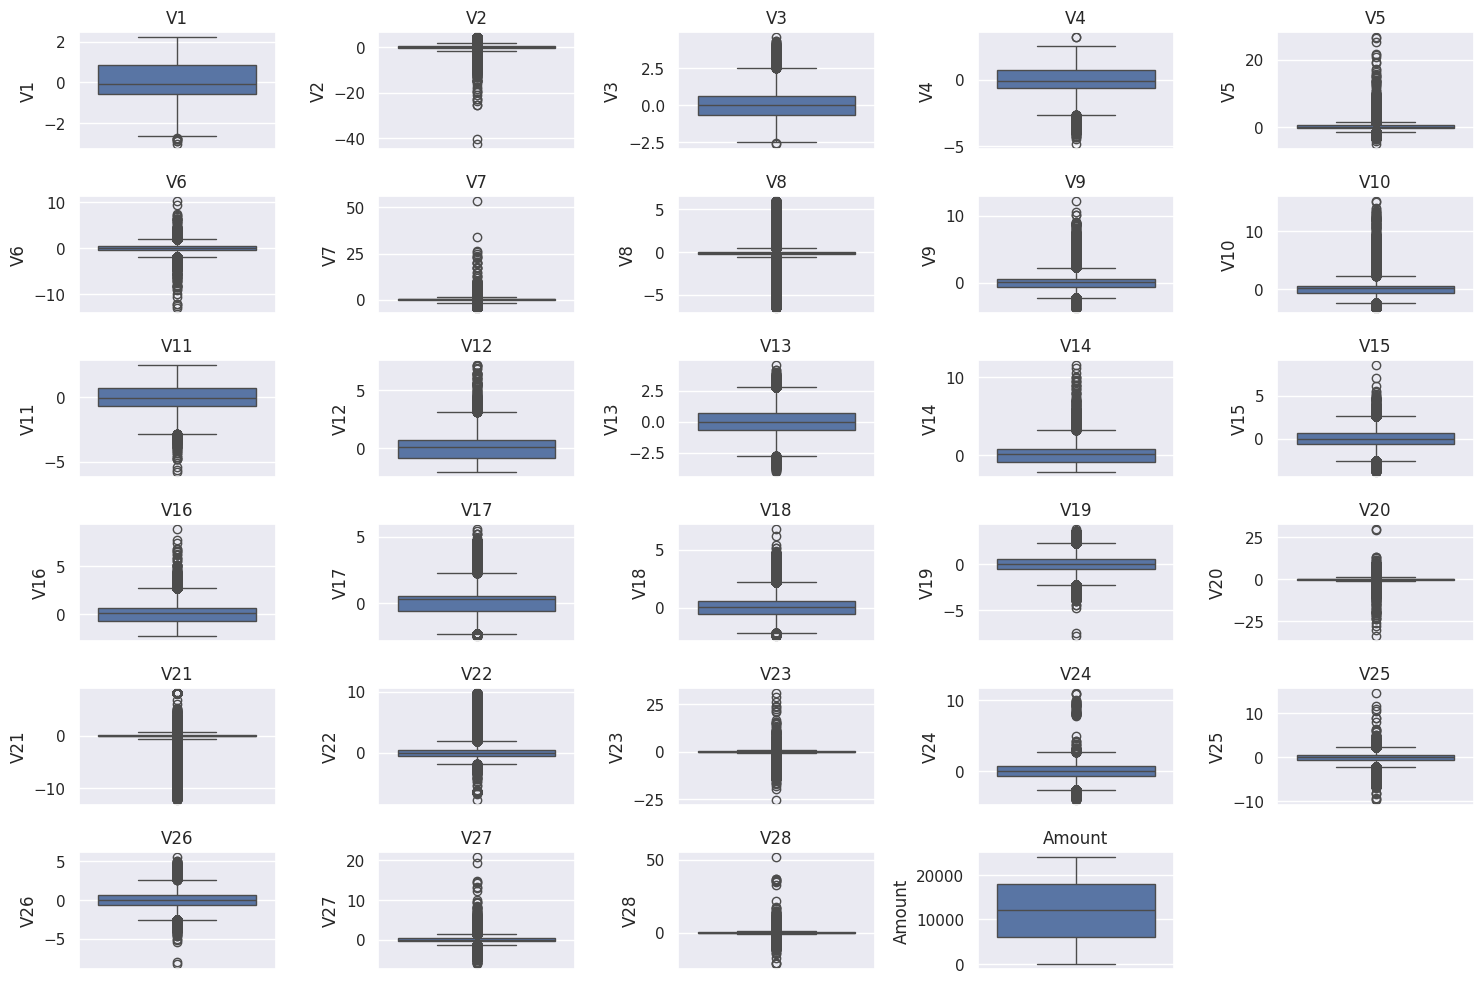

In [ ]:


num_cols = df.select_dtypes(include=np.number).columns
num_cols = num_cols.drop('Class')

plt.figure(figsize=(15,10))
for i, col in enumerate(num_cols):
    plt.subplot(6, 5, i + 1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()



*   É possível notar a presença de outliers na maioria das variáveis - esses outliers não vão ser descartados e vão ser aproveitados na etapa de preparação dos dados.



# 3. Preparando os dados


Para facilitar o processamento do modelo, separei 30% do dataset apenas nessa etapa.



In [ ]:
df= df.sample(frac=0.3, random_state=42)

In [ ]:
# Separando dados de treino e dados de teste
X = df.drop(columns=['Class'])
y = df['Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train.shape, X_test.shape

((136471, 32), (34118, 32))

In [ ]:
#Aplicando clustering para criar uma nova feature 'subgrupo'

from sklearn.cluster import KMeans

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

kmeans = KMeans(n_clusters=5, random_state=42)
subgrupos_train = kmeans.fit_predict(X_train_scaled)


X_train = X_train.reset_index(drop=True)
X_train['subgrupo'] = subgrupos_train

subgrupos_test = kmeans.predict(X_test_scaled)

X_test = X_test.reset_index(drop=True)
X_test['subgrupo'] = subgrupos_test


In [ ]:
from sklearn.ensemble import IsolationForest

# Identificando anomalias usando o Isolation Forest
clf = IsolationForest(random_state=42, contamination=0.1)
clf.fit(X_train)
y_pred_train = clf.predict(X_train)
y_pred_test = clf.predict(X_test)

y_score_train = clf.decision_function(X_train)
y_score_test = clf.decision_function(X_test)

# Adicionando as predições de anomalia como uma nova coluna nos dados originais
X_train['IsOutlier'] = y_pred_train
X_test['IsOutlier'] = y_pred_test

X_train['AnomalyScore'] = y_score_train
X_test['AnomalyScore'] = y_score_test

In [ ]:
X_train.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V23,V24,V25,V26,V27,V28,Amount,subgrupo,IsOutlier,AnomalyScore
0,-1.204102,1.207031,-1.302734,0.731934,-1.210938,-1.572266,-0.955566,1.256836,-0.663086,-0.934570,...,0.140259,-0.074707,0.567383,-0.627930,1.405273,0.515137,16640.0,2,1,0.053099
1,-1.225586,-2.250000,-0.657227,-0.092468,-0.644531,-0.282227,-0.078186,0.149658,-0.322510,-0.386719,...,-2.515625,-0.550781,-0.496826,-0.542480,-0.151611,-2.269531,14656.0,3,1,0.058692
2,-0.084167,-2.480469,-0.513184,-0.242676,0.053650,0.278809,1.686523,-0.320557,0.422852,0.398193,...,-1.393555,-1.499023,-0.236816,0.139771,-0.630371,0.299316,6564.0,1,1,0.049244
3,-0.137085,-0.011192,0.860840,-0.691895,0.164307,0.134644,0.478271,-0.007828,0.275635,0.511719,...,-0.014282,-0.147461,-0.279541,0.211060,0.015930,0.089172,12336.0,1,1,0.123885
4,1.494141,-0.859863,0.290283,-0.473633,0.107422,1.281250,0.098999,-0.012825,0.335449,1.127930,...,0.420166,-2.443359,-1.310547,-2.154297,-0.110779,-0.179688,13664.0,1,1,0.050696


In [ ]:
X_train['subgrupo'].value_counts()

,count
subgrupo,
4,53605
3,37717
1,27248
2,15678
0,2223


# 4. Modelo & Avaliação

*Nessa etapa foi utilizada a métrica **f1_score** e a **matriz de confusão** para
fazer a avaliação, e o modelo escolhido foi o **Random Forest Classifier**.*

In [ ]:
model = RandomForestClassifier(random_state= 9)
model.fit(X_train,y_train)
pred = model.predict(X_test)

In [ ]:
f1 = f1_score(y_test, pred)
print("F1 Score:", f1)

F1 Score: 0.9997075339260646


In [ ]:
confusion_matrix(y_test,pred)

array([[17017,     6],
       [    4, 17091]])

In [ ]:
auc = roc_auc_score(y_test, pred)

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test,pred)

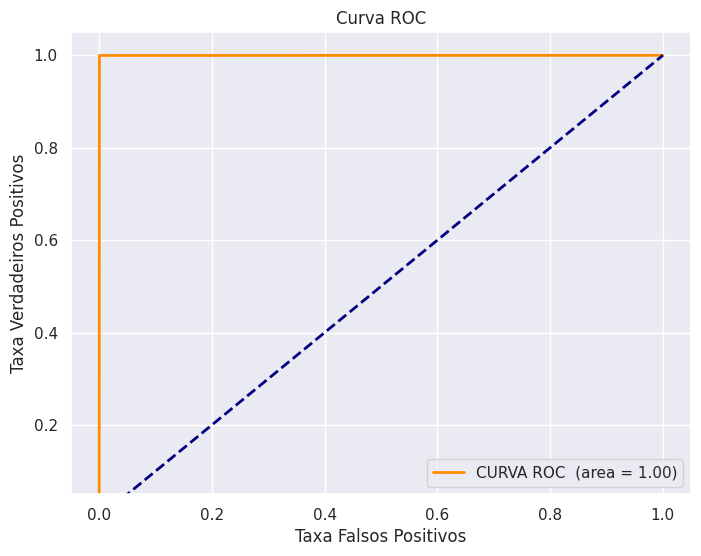

In [ ]:
# Plotando a curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='CURVA ROC  (area = %0.2f)' % auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.ylim([0.05, 1.05])
plt.xlabel('Taxa Falsos Positivos')
plt.ylabel('Taxa Verdadeiros Positivos')
plt.title('Curva ROC')
plt.legend(loc="lower right")
plt.show()

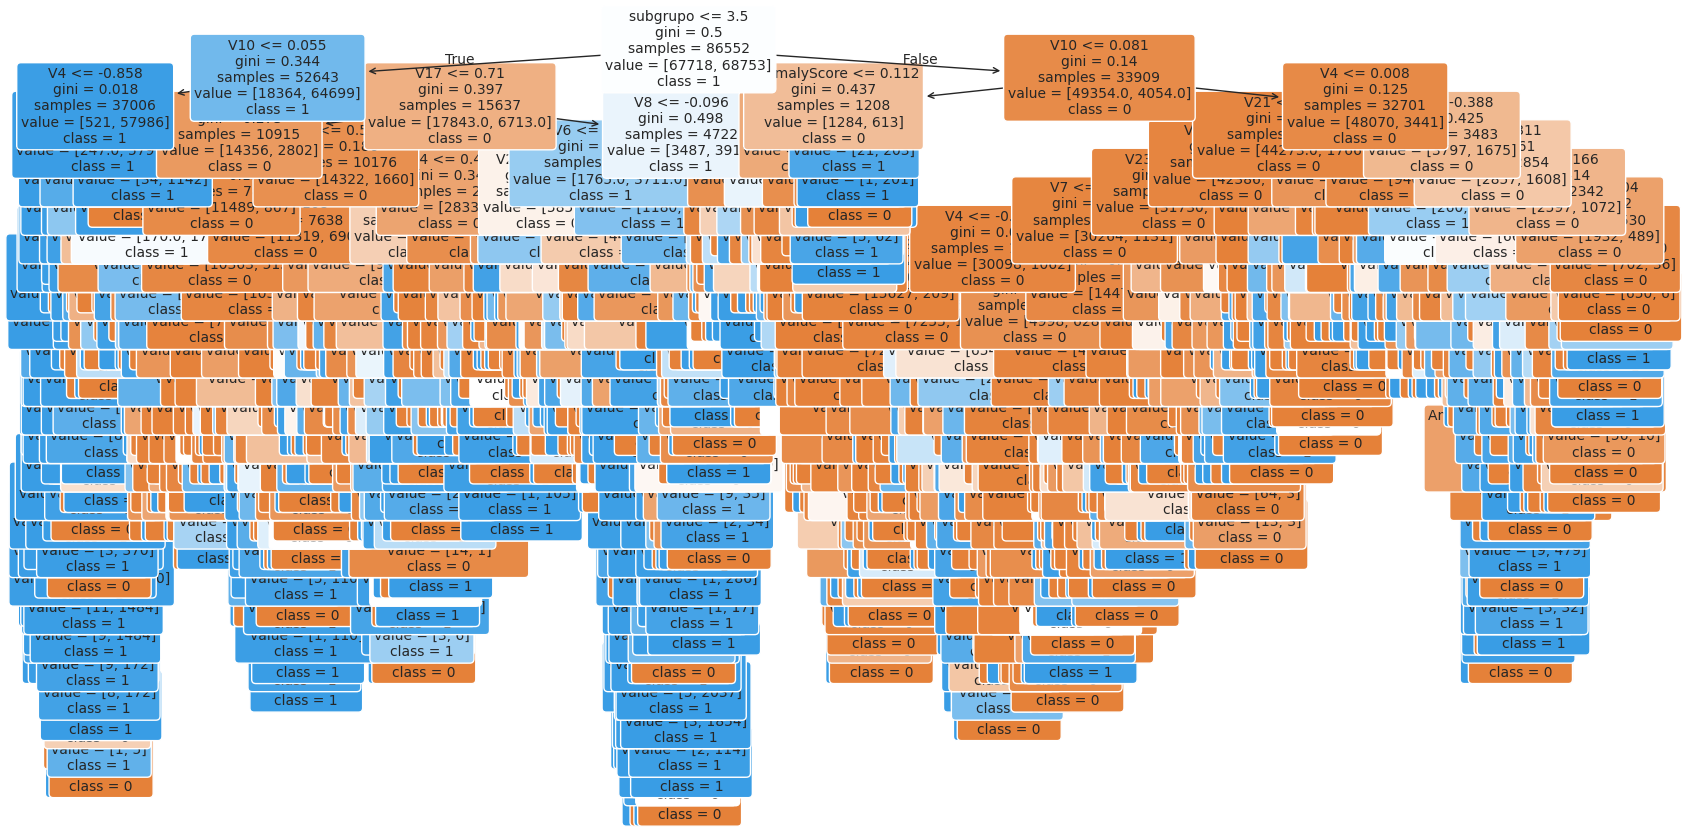

In [ ]:
#Plotando o gráfico da árvore de decisão
plt.figure(figsize=(20, 10))
plot_tree(model.estimators_[0],
          feature_names=X_train.columns,
          class_names=['0', '1'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.show()

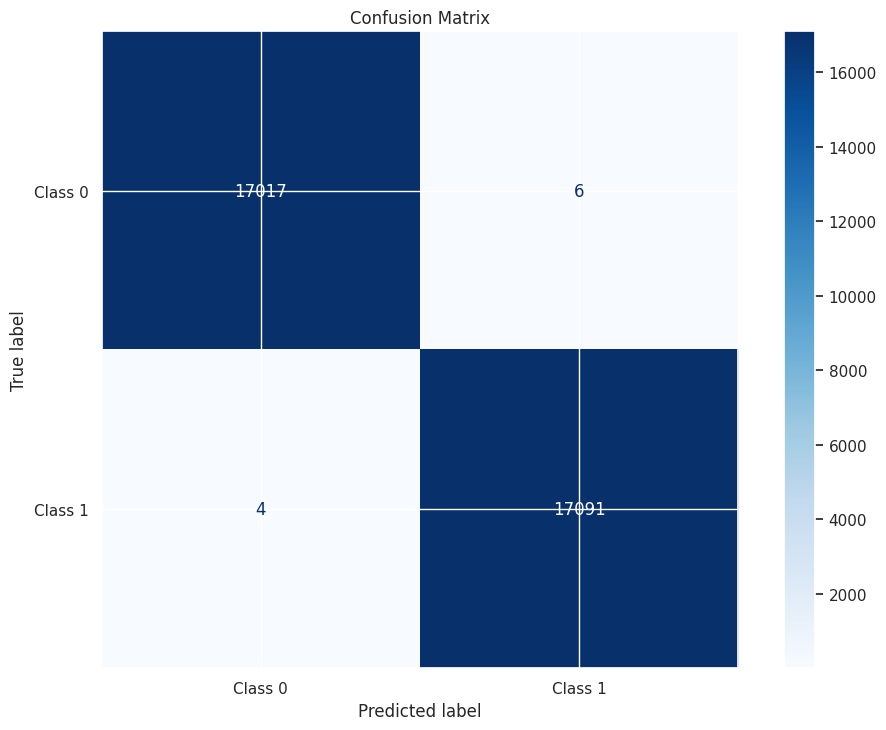

In [ ]:
conf_matrix = confusion_matrix(y_test, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Class 0', 'Class 1'])

# Plotando a matriz de confusão
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

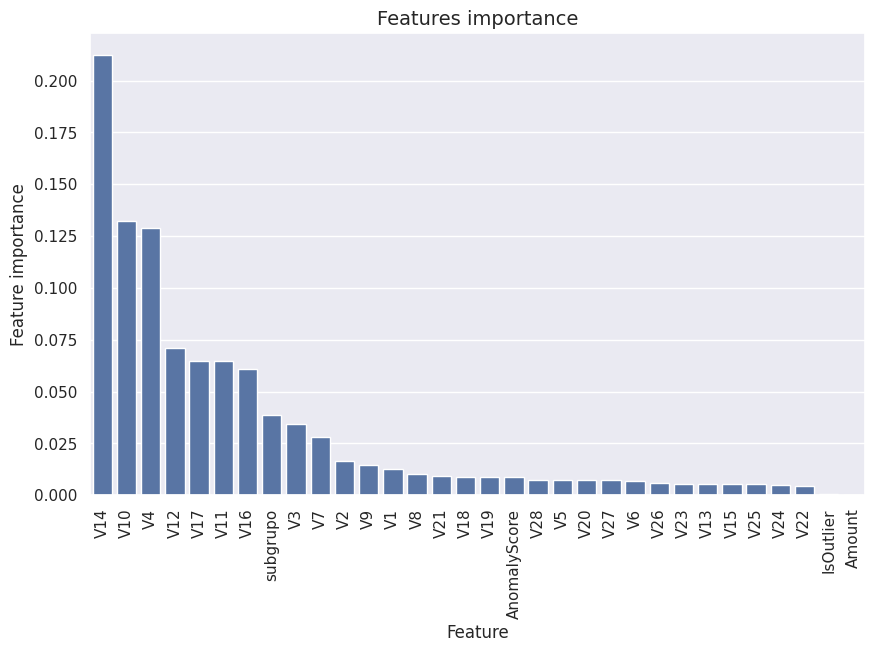

In [ ]:
df_importance = pd.DataFrame({'Feature': X_train.columns, 'Feature importance': model.feature_importances_})
df_importance = df_importance.sort_values(by='Feature importance',ascending=False)
plt.figure(figsize = (10,6))
plt.title('Features importance',fontsize=14)
s = sns.barplot(x='Feature',y='Feature importance',data=df_importance)
s.set_xticklabels(s.get_xticklabels(),rotation=90)
plt.show()

In [ ]:
model2= RandomForestClassifier(random_state=42, max_depth=5, n_estimators=10)
model2.fit(X_train,y_train)
pred2 = model2.predict(X_test)

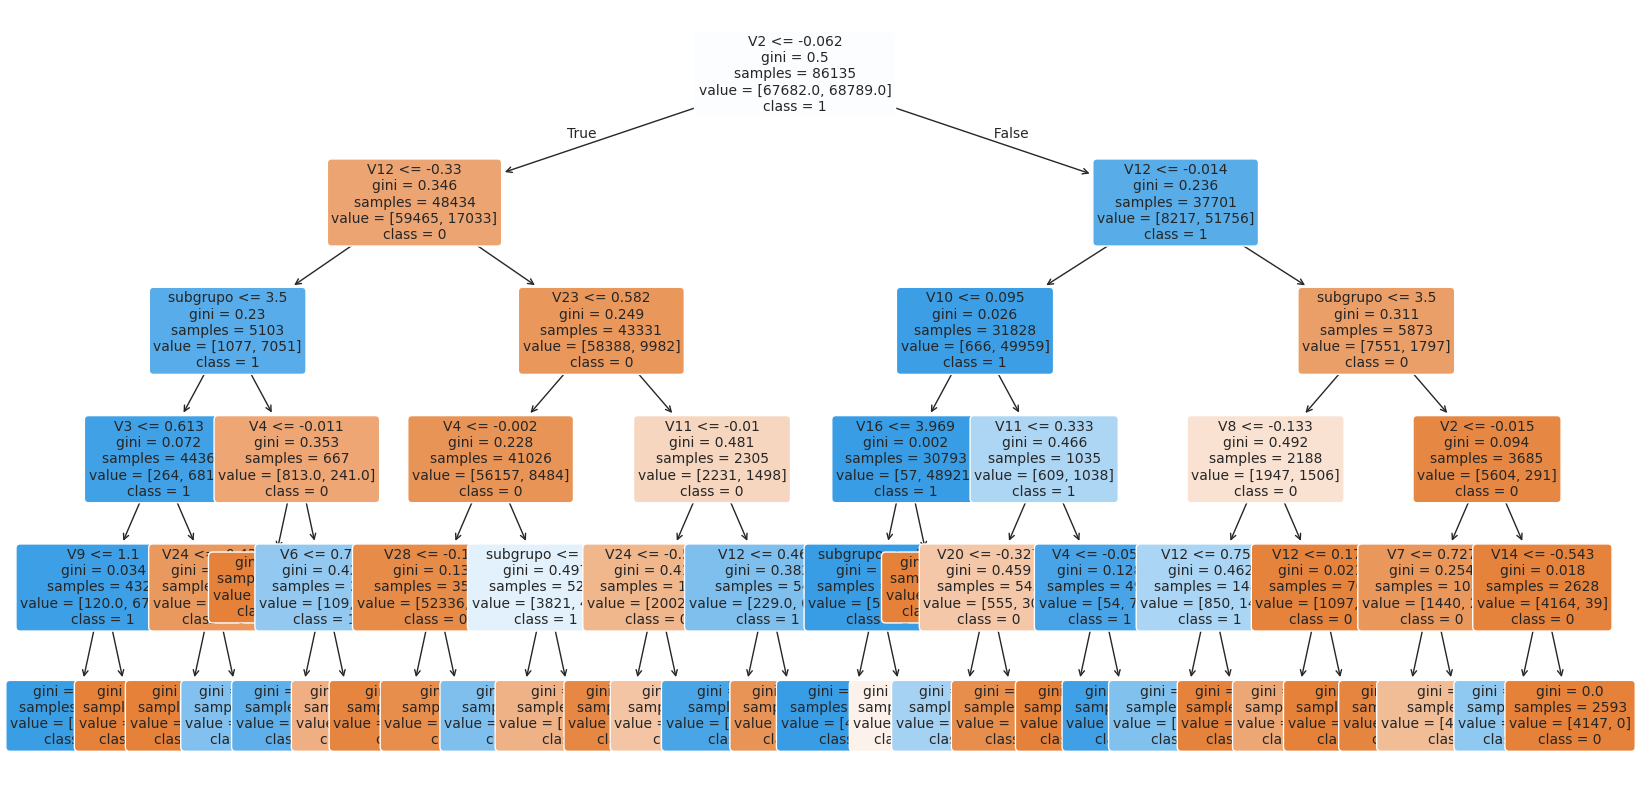

In [ ]:
#Gráfico árvore de decisão de uma árvore com menor profundidade
plt.figure(figsize=(20, 10))
plot_tree(model2.estimators_[0],
          feature_names=X_train.columns,
          class_names=['0', '1'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.show()

In [ ]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 364.4/364.4 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.5/233.5 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 6.7 MB/s eta 0:00:00


In [ ]:
import optuna
from sklearn.metrics import brier_score_loss

In [ ]:
def objective(trial):
    # Definindo o espaço de busca dos hiperparâmetros
    n_estimators = trial.suggest_int('n_estimators', 50, 100)
    max_depth = trial.suggest_int('max_depth', 2, 32, log=True)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 15)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 15)

    # Criando o modelo com os hiperparâmetros sugeridos
    modelo = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42
    )

    # Treinando o modelo
    modelo.fit(X_train, y_train)
    predicted = modelo.predict(X_test)

    #  usando o F1 Score
    f1 = f1_score(y_test, predicted, average='weighted')
    return -f1
# Executando a otimização
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20)

# Mostrando os melhores hiperparâmetros
print("Best hyperparameters: ", study.best_params)

best_model_rf = RandomForestClassifier(**study.best_params)

[I 2024-11-27 21:37:42,884] A new study created in memory with name: no-name-e25c3548-0e8d-40de-a4d4-c018d3b1ac79
[I 2024-11-27 21:37:51,275] Trial 0 finished with value: -0.9334948249527408 and parameters: {'n_estimators': 62, 'max_depth': 2, 'min_samples_split': 3, 'min_samples_leaf': 7}. Best is trial 0 with value: -0.9334948249527408.
[I 2024-11-27 21:38:03,161] Trial 1 finished with value: -0.9336728623464503 and parameters: {'n_estimators': 77, 'max_depth': 2, 'min_samples_split': 6, 'min_samples_leaf': 1}. Best is trial 1 with value: -0.9336728623464503.
[I 2024-11-27 21:39:30,307] Trial 2 finished with value: -0.9991500092070426 and parameters: {'n_estimators': 96, 'max_depth': 29, 'min_samples_split': 12, 'min_samples_leaf': 8}. Best is trial 2 with value: -0.9991500092070426.
[I 2024-11-27 21:40:27,844] Trial 3 finished with value: -0.9925843304285856 and parameters: {'n_estimators': 75, 'max_depth': 12, 'min_samples_split': 10, 'min_samples_leaf': 5}. Best is trial 2 with va

Best hyperparameters:  {'n_estimators': 82, 'max_depth': 22, 'min_samples_split': 8, 'min_samples_leaf': 3}


Best hyperparameters:  {'n_estimators': 82, 'max_depth': 22, 'min_samples_split': 8, 'min_samples_leaf': 3}

Best hyperparameters:  {'n_estimators': 74, 'max_depth': 27, 'min_samples_split': 2, 'min_samples_leaf': 6}

In [ ]:
model4= RandomForestClassifier(random_state=42, max_depth=22, n_estimators=82, min_samples_split=8, min_samples_leaf=3)
model4.fit(X_train,y_train)
pred4 = model4.predict(X_test)

In [ ]:
f1 = f1_score(y_test, pred4)
print("F1 Score:", f1)

F1 Score: 0.9994149651904288


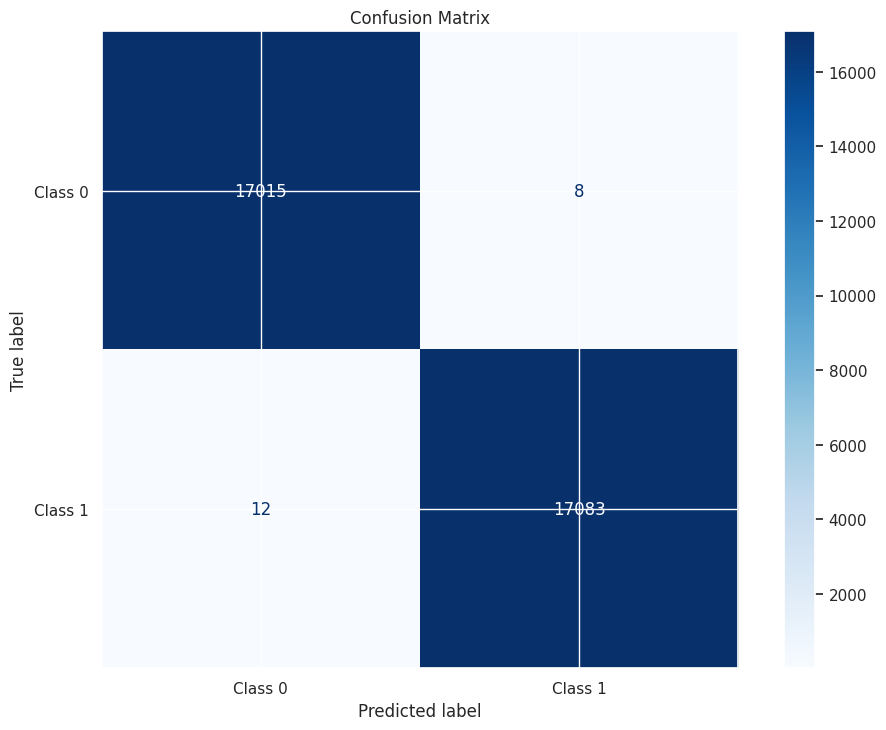

In [ ]:
conf_matrix = confusion_matrix(y_test, pred4)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Class 0', 'Class 1'])

# Plotando a matriz de confusão
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()